In [3]:
import pandas as pd
import numpy as np
import subprocess
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
# Corrected import for FeatureUnion
from sklearn.pipeline import Pipeline, FeatureUnion 

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve
from gtda.pipeline import make_pipeline

# 1. Load the dataset
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

# 2. Identify the target column
target_col = 'type' 
if target_col not in df.columns:
    # Fallback if the label is in the first column
    target_col = df.columns[0] 

X = df.drop(columns=[target_col]).values
y = df[target_col].values

# 3. Encode categorical target labels to numeric values
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Data shape: {X.shape}")
print(f"Found subtypes: {le.classes_}")

Data shape: (151, 54676)
Found subtypes: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve
from gtda.pipeline import make_pipeline
from sklearn.pipeline import FeatureUnion, make_pipeline as make_sklearn_pipeline
from sklearn.preprocessing import FunctionTransformer

# 1. Load the dataset
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = 'type' 
if target_col not in df.columns:
    target_col = df.columns[0] 

X = df.drop(columns=[target_col]).values
y = df[target_col].values

# 2. Encode categorical target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Standardize gene expression data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- CRITICAL FIX: Feature Selection ---
# Reduce from 54,674 genes to the top 3000 to avoid $O(N^2)$ memory blow-up in the distance matrix
n_features_to_keep = 3000
selector = SelectKBest(score_func=f_classif, k=n_features_to_keep)
X_reduced = selector.fit_transform(X_scaled, y_encoded)

print(f"Original shape: {X_scaled.shape}")
print(f"Reduced shape for TDA: {X_reduced.shape}")

# TDA Parameters
embedding_dimension = 3
embedding_time_delay = 1
homology_dimensions = [0, 1] 

# 4. Transform each reduced sample into a point cloud 
embedder = SingleTakensEmbedding(
    parameters_type="fixed",
    n_jobs=-1,
    time_delay=embedding_time_delay,
    dimension=embedding_dimension
)

X_embedded = [embedder.fit_transform(x) for x in X_reduced]

# 5. Initialize Vietoris-Rips persistence computation
VR = VietorisRipsPersistence(homology_dimensions=homology_dimensions, n_jobs=-1)

# # 6. Feature Extraction
# tda_features = FeatureUnion([
#     ("landscape", PersistenceLandscape(n_bins=100)),
#     ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
#     ("amplitude_bottleneck", Amplitude(metric="bottleneck")),
#     ("betti", BettiCurve(n_bins=100))
# ])

# tda_pipeline = make_pipeline(VR, tda_features)

# 1. Create a simple flattener to collapse 3D tensors into 2D matrices
# This changes shape from [samples, homology_dims, bins] to [samples, homology_dims * bins]
flattener = FunctionTransformer(lambda X: X.reshape(X.shape[0], -1))

# 2. Update FeatureUnion to flatten the 3D outputs
tda_features = FeatureUnion([
    # Landscapes output 3D -> needs flattening
    ("landscape", make_sklearn_pipeline(
        PersistenceLandscape(n_bins=100), 
        flattener
    )),
    
    # Amplitudes output 2D natively -> no flattening needed
    ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
    ("amplitude_bottleneck", Amplitude(metric="bottleneck")),
    
    # Betti curves output 3D -> needs flattening
    ("betti", make_sklearn_pipeline(
        BettiCurve(n_bins=100), 
        flattener
    ))
])

# The rest of your pipeline remains the same
tda_pipeline = make_pipeline(VR, tda_features)

print("Computing Rips complexes and extracting features...")
X_tda = tda_pipeline.fit_transform(X_embedded)
print(f"Shape of topological features: {X_tda.shape}")

# print("Computing Rips complexes and extracting features...")
# X_tda = tda_pipeline.fit_transform(X_embedded)
# print(f"Shape of topological features: {X_tda.shape}")

# 7. Classification
X_train, X_test, y_train, y_test = train_test_split(
    X_tda, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\n=== Classification Report (Topological Features) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Original shape: (151, 54676)
Reduced shape for TDA: (151, 3000)
Computing Rips complexes and extracting features...
Shape of topological features: (151, 404)
Computing Rips complexes and extracting features...
Shape of topological features: (151, 404)

=== Classification Report (Topological Features) ===
Accuracy: 0.4783

              precision    recall  f1-score   support

         HER       0.57      0.44      0.50         9
       basal       0.41      0.54      0.47        13
   cell_line       0.80      1.00      0.89         4
   luminal_A       0.44      0.44      0.44         9
   luminal_B       0.29      0.22      0.25         9
      normal       1.00      0.50      0.67         2

    accuracy                           0.48        46
   macro avg       0.59      0.52      0.54        46
weighted avg       0.48      0.48      0.47        46



In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

# 1. Load the dataset
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = 'type' 
if target_col not in df.columns:
    target_col = df.columns[0] 

X = df.drop(columns=[target_col]).values
y = df[target_col].values

# 2. Encode categorical target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 3. Define the full pipeline
# Flattener for 3D outputs (Landscapes, Betti) to make them compatible with FeatureUnion
flattener = FunctionTransformer(lambda X: X.reshape(X.shape[0], -1))

tda_features = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=100)), 
        ("flatten", flattener)
    ])),
    ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=100)), 
        ("flatten", flattener)
    ]))
])

# The complete pipeline using batch TakensEmbedding
full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
    # Removed 'parameters_type' and 'n_jobs' to match the class signature
    ('embedding', TakensEmbedding(time_delay=4, dimension=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# 4. Evaluate using 3-Fold Cross-Validation
print(f"Dataset summary: {X.shape[0]} samples, {X.shape[1]} features.")
print("Evaluating the topological pipeline with Stratified 3-Fold Cross-Validation...")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = cross_validate(
    full_pipeline, X, y_encoded, 
    cv=cv, 
    scoring=('accuracy', 'f1_macro'),
    n_jobs=1, 
    return_train_score=False
)

print(f"\n=== Cross-Validation Results ===")
print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"Mean CV F1-Macro: {np.mean(cv_results['test_f1_macro']):.4f} (+/- {np.std(cv_results['test_f1_macro']):.4f})")

Dataset summary: 151 samples, 54676 features.
Evaluating the topological pipeline with Stratified 3-Fold Cross-Validation...

=== Cross-Validation Results ===
Mean CV Accuracy: 0.5758 (+/- 0.0678)
Mean CV F1-Macro: 0.5815 (+/- 0.1004)


In [12]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid for TakensEmbedding
# The double underscore '__' connects the pipeline step name to its parameter
param_grid = {
    'embedding__time_delay': [1, 2, 3],
    'embedding__dimension': [2, 3, 4],
    # You can also tune the classifier simultaneously:
    # 'classifier__n_estimators': [50, 100]
}

# 2. Initialize GridSearchCV wrapping our existing full_pipeline
print("Starting Grid Search to find optimal Takens parameters without guessing...")

grid_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=1, # Keep 1 at this level to avoid nested parallelization issues with TDA
    verbose=2
)

# 3. Fit the Grid Search (This will take time as it runs the pipeline for every combination)
grid_search.fit(X, y_encoded)

# 4. Results
print("\n=== Best Parameters Found ===")
print(grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# The grid_search object can now be used as a predictor with the best parameters automatically
# y_pred = grid_search.predict(X_test)

Starting Grid Search to find optimal Takens parameters without guessing...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END ....embedding__dimension=2, embedding__time_delay=1; total time= 2.1min
[CV] END ....embedding__dimension=2, embedding__time_delay=1; total time= 1.7min
[CV] END ....embedding__dimension=2, embedding__time_delay=1; total time= 1.7min
[CV] END ....embedding__dimension=2, embedding__time_delay=2; total time= 1.7min
[CV] END ....embedding__dimension=2, embedding__time_delay=2; total time= 1.8min
[CV] END ....embedding__dimension=2, embedding__time_delay=2; total time= 1.6min
[CV] END ....embedding__dimension=2, embedding__time_delay=3; total time= 1.6min
[CV] END ....embedding__dimension=2, embedding__time_delay=3; total time= 1.6min
[CV] END ....embedding__dimension=2, embedding__time_delay=3; total time= 1.6min
[CV] END ....embedding__dimension=3, embedding__time_delay=1; total time= 1.9min
[CV] END ....embedding__dimension=3, embedding__time_de

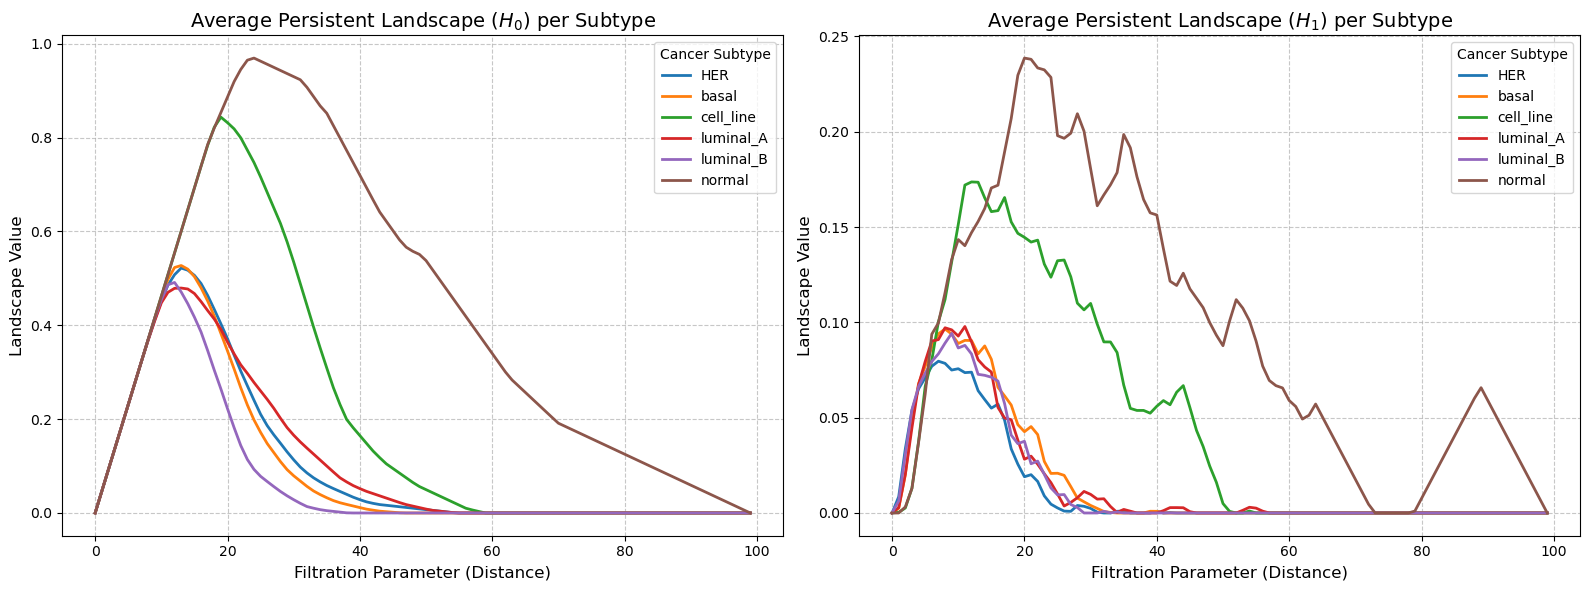

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# 1. Recreate the TDA steps using the optimal parameters (3-3)
optimal_embedder = TakensEmbedding(time_delay=3, dimension=3)
X_embedded_opt = optimal_embedder.fit_transform(X_reduced)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams = rips.fit_transform(X_embedded_opt)

# Extract landscapes
# Output shape: [n_samples, n_homology_dimensions, n_bins]
landscape_extractor = PersistenceLandscape(n_bins=100)
landscapes = landscape_extractor.fit_transform(diagrams)

# 2. Setup plotting
homology_dims = [0, 1]
classes = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Calculate mean landscapes per class and plot
for class_idx, class_name in enumerate(classes):
    # Find all sample indices belonging to the current cancer subtype
    sample_indices = np.where(y_encoded == class_idx)[0]
    
    # Isolate landscapes for this specific subtype
    class_landscapes = landscapes[sample_indices]
    
    # Calculate the mathematical average across the samples (axis=0)
    # The resulting shape is [n_homology_dimensions, n_bins]
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    # Plot H0 (Connected Components)
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    
    # Plot H1 (1-Dimensional Holes / Loops)
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

# Formatting H0 plot
axes[0].set_title('Average Persistent Landscape ($H_0$) per Subtype', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Formatting H1 plot
axes[1].set_title('Average Persistent Landscape ($H_1$) per Subtype', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
# Using the standalone Python ripser package
from ripser import ripser 

class CustomRipserTransformer(BaseEstimator, TransformerMixin):
    """
    A custom scikit-learn transformer that replaces giotto-tda's VietorisRipsPersistence.
    It computes persistence diagrams using the standard 'ripser' library and pads 
    the output into the strict 3D tensor required by giotto-tda feature extractors.
    """
    def __init__(self, maxdim=1, thresh=np.inf):
        self.maxdim = maxdim
        self.thresh = thresh

    def fit(self, X, y=None):
        # Nothing to fit, simply return self
        return self

    def transform(self, X, y=None):
        diagrams_list = []
        
        # X is expected to be an iterable of point clouds (e.g., from TakensEmbedding)
        for point_cloud in X:
            # 1. Calculate persistence using standard ripser
            # Note: If you want to use your C++ binary instead, you would replace this 
            # call with subprocess.run() exactly as shown in the initial Cell 2 example,
            # and parse the string output back into numpy arrays.
            res = ripser(point_cloud, maxdim=self.maxdim, thresh=self.thresh)
            dgms = res['dgms']
            
            # 2. Format into [birth, death, dimension] stack
            sample_dgm = []
            for dim, dgm in enumerate(dgms):
                if len(dgm) > 0:
                    # Append the homology dimension as a 3rd column
                    dim_col = np.full((dgm.shape[0], 1), dim)
                    dgm_with_dim = np.hstack([dgm, dim_col])
                    sample_dgm.append(dgm_with_dim)
            
            if len(sample_dgm) > 0:
                diagrams_list.append(np.vstack(sample_dgm))
            else:
                diagrams_list.append(np.empty((0, 3)))
        
        # 3. Pad diagrams to create a homogeneous 3D tensor for giotto-tda extractors
        # Find the maximum number of topological features across all samples in the batch
        max_points = max([len(dgm) for dgm in diagrams_list]) if diagrams_list else 0
        
        # Initialize a tensor of zeros. 
        # giotto-tda ignores features where birth == death (which [0, 0, 0] perfectly satisfies)
        padded_diagrams = np.zeros((len(X), max_points, 3))
        
        for i, dgm in enumerate(diagrams_list):
            n_points = len(dgm)
            if n_points > 0:
                padded_diagrams[i, :n_points, :] = dgm
                
        return padded_diagrams

In [21]:
import numpy as np
import pandas as pd
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

def calculate_ami_continuous(x, y, bins=50):
    """
    Calculates the Mutual Information between two continuous vectors
    by estimating their joint probability distribution via a 2D histogram.
    """
    # H is the 2D histogram (contingency table)
    H, _, _ = np.histogram2d(x, y, bins=bins)
    return mutual_info_score(None, None, contingency=H)

def find_optimal_tau_via_ami(X, max_tau=20, bins=50):
    """
    Finds the optimal time delay (tau) by calculating the Average Mutual Information (AMI)
    across all samples and locating the first local minimum.
    """
    mean_amis = []
    
    for tau in range(1, max_tau + 1):
        amis_for_tau = []
        for sample in X:
            # Shift the signal against itself by tau
            x_t = sample[:-tau]
            x_t_plus_tau = sample[tau:]
            
            ami = calculate_ami_continuous(x_t, x_t_plus_tau, bins=bins)
            amis_for_tau.append(ami)
            
        # Average AMI across all patients for this specific tau
        mean_amis.append(np.mean(amis_for_tau))
        
    mean_amis = np.array(mean_amis)
    
    # Find the first local minimum
    diffs = np.diff(mean_amis)
    # A local minimum occurs where the difference transitions from negative to positive
    local_mins = np.where(diffs > 0)[0] 
    
    if len(local_mins) > 0:
        # +1 because tau is 1-indexed (starts at 1) and diff shifts index by 1
        optimal_tau = local_mins[0] + 1 
        print(f"First local minimum found at tau = {optimal_tau}")
    else:
        # Fallback if the function is monotonically decreasing
        optimal_tau = np.argmin(mean_amis) + 1
        print(f"No local minimum found. Taking global minimum at tau = {optimal_tau}")
        
    return optimal_tau, mean_amis

# --- Execution ---
# Assuming X_scaled and y_encoded are already prepared from the dataset
# We perform AMI on the REDUCED feature set to match what the embedder will actually see
selector = SelectKBest(score_func=f_classif, k=3000)
X_reduced_for_ami = selector.fit_transform(StandardScaler().fit_transform(X), y_encoded)

print("Calculating optimal time delay using Average Mutual Information...")
optimal_tau, ami_values = find_optimal_tau_via_ami(X_reduced_for_ami, max_tau=60)

Calculating optimal time delay using Average Mutual Information...
First local minimum found at tau = 4


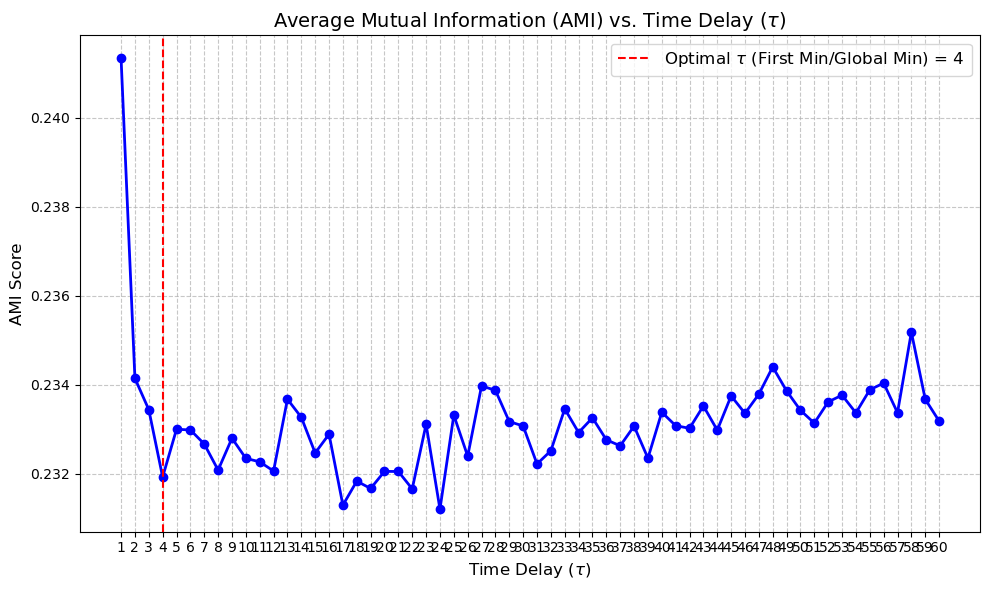


Evaluating pipeline using native VietorisRipsPersistence with fixed tau=4...
n_bins =  10 | Test Accuracy: 0.4767 | Train Accuracy: 1.0000
n_bins =  50 | Test Accuracy: 0.5233 | Train Accuracy: 1.0000
n_bins = 100 | Test Accuracy: 0.5034 | Train Accuracy: 1.0000
n_bins = 200 | Test Accuracy: 0.5301 | Train Accuracy: 1.0000


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

# --- 1. Plotting the AMI Results ---
# Assuming 'ami_values' and 'optimal_tau' were calculated in the previous step
# We cast optimal_tau to a native Python int to satisfy giotto-tda type checkers
optimal_tau = int(optimal_tau)

tau_values = range(1, len(ami_values) + 1)

plt.figure(figsize=(10, 6))
plt.plot(tau_values, ami_values, marker='o', linestyle='-', color='b', linewidth=2)
plt.axvline(x=optimal_tau, color='r', linestyle='--', 
            label=f'Optimal $\\tau$ (First Min/Global Min) = {optimal_tau}')

plt.title('Average Mutual Information (AMI) vs. Time Delay ($\\tau$)', fontsize=14)
plt.xlabel('Time Delay ($\\tau$)', fontsize=12)
plt.ylabel('AMI Score', fontsize=12)
plt.xticks(tau_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# --- 2. Evaluating the Pipeline with fixed tau and varying n_bins ---

bin_resolutions = [10, 50, 100, 200]
results_n_bins = {}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

print(f"\nEvaluating pipeline using native VietorisRipsPersistence with fixed tau={optimal_tau}...")

for bins in bin_resolutions:
    # Dynamically construct the TDA features block
    tda_features = FeatureUnion([
        ("landscape", Pipeline([
            ("extract", PersistenceLandscape(n_bins=bins)), 
            ("flatten", flattener)
        ])),
        ("amplitude_wasserstein", Amplitude(metric="wasserstein")),
        ("betti", Pipeline([
            ("extract", BettiCurve(n_bins=bins)), 
            ("flatten", flattener)
        ]))
    ])

    # Construct the full pipeline using giotto-tda's internal Rips engine
    full_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
        ('embedding', TakensEmbedding(time_delay=optimal_tau, dimension=3)),
        
        # Reverted back to VietorisRipsPersistence
        ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
        
        ('tda_features', tda_features),
        ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
    ])

    # Evaluate the pipeline
    try:
        cv_results = cross_validate(
            full_pipeline, X, y_encoded, 
            cv=cv, 
            scoring=('accuracy', 'f1_macro'),
            n_jobs=1,
            return_train_score=True 
        )
        
        mean_test_acc = np.mean(cv_results['test_accuracy'])
        mean_train_acc = np.mean(cv_results['train_accuracy'])
        
        results_n_bins[bins] = mean_test_acc
        
        print(f"n_bins = {bins:3d} | Test Accuracy: {mean_test_acc:.4f} | Train Accuracy: {mean_train_acc:.4f}")
        
    except Exception as e:
        print(f"n_bins = {bins:3d} | Failed with error: {e}")

In [23]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 1. Load Data
df = pd.read_csv('Breast_GSE45827.csv')
target_col = df.columns[0] if 'type' not in df.columns else 'type'

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Baseline ML Pipeline
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# 3. Evaluate Baseline
print("Evaluating Baseline Random Forest (No TDA)...")
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
baseline_results = cross_validate(
    baseline_pipeline, X, y_encoded, 
    cv=cv, scoring=('accuracy', 'f1_macro')
)

print(f"Baseline Accuracy: {np.mean(baseline_results['test_accuracy']):.4f}")
print(f"Baseline F1-Macro: {np.mean(baseline_results['test_f1_macro']):.4f}")

Evaluating Baseline Random Forest (No TDA)...
Baseline Accuracy: 0.9271
Baseline F1-Macro: 0.9256


In [1]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.decomposition import PCA

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

class SingleSampleNetworkTopology(BaseEstimator, TransformerMixin):
    """
    Transforms tabular gene expression data into patient-specific 3D point clouds
    based on the global Gene Co-expression Network topology.
    """
    def __init__(self, n_active_genes=100, embedding_dim=3):
        self.n_active_genes = n_active_genes
        self.embedding_dim = embedding_dim
        self.gene_coords_ = None

    def fit(self, X, y=None):
        # 1. Compute global correlation matrix across all training samples
        # X shape is (n_samples, n_genes). We transpose to correlate genes.
        # Add a tiny constant to avoid division by zero in perfectly flat genes
        corr = np.corrcoef(X.T + np.random.normal(0, 1e-8, X.T.shape))
        corr = np.nan_to_num(corr, nan=0.0)
        
        # 2. Convert correlation to distance: d = 1 - |r|
        # Highly correlated (or anti-correlated) genes have distance near 0
        dist_matrix = 1 - np.abs(corr)
        
        # 3. Embed the global gene network into a 3D geometric space
        # We use PCA on the distance matrix to get spatial coordinates for each gene
        pca = PCA(n_components=self.embedding_dim, random_state=42)
        self.gene_coords_ = pca.fit_transform(dist_matrix)
        
        return self

    def transform(self, X, y=None):
        point_clouds = []
        
        for sample in X:
            # 1. Find the indices of the most highly expressed genes for this specific patient
            # Since X is standard-scaled before this step, higher positive values = overexpressed
            top_gene_indices = np.argsort(sample)[-self.n_active_genes:]
            
            # 2. Retrieve the 3D spatial coordinates of these active genes
            patient_cloud = self.gene_coords_[top_gene_indices]
            point_clouds.append(patient_cloud)
            
        # Returns a 3D tensor: [n_samples, n_active_genes, 3] which giotto-tda loves
        return np.array(point_clouds)

# --- 1. Load Data ---
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# --- 2. Build the Topological Pipeline ---
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_features = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

full_pipeline = Pipeline([
    # Step 1: Scale genes to Z-scores (essential for finding overexpressed genes later)
    ('scaler', StandardScaler()),
    
    # Step 2: Global feature selection to avoid computing a 54k x 54k correlation matrix (Memory Error)
    # We reduce to the top 1000 most informative genes across the dataset
    ('feature_selection', SelectKBest(score_func=f_classif, k=1000)),
    
    # Step 3: Our custom Transformer (Creates a network-based 3D point cloud per patient)
    # Each patient gets a point cloud of their 100 most active genes from the 1000 pool
    ('ssn_topology', SingleSampleNetworkTopology(n_active_genes=100, embedding_dim=3)),
    
    # Step 4: Standard Vietoris-Rips on the 3D point clouds
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    
    # Step 5: Flatten TDA outputs
    ('tda_features', tda_features),
    
    # Step 6: Final Classifier
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# --- 3. Evaluate the Pipeline ---
print("Evaluating Single-Sample Network Topology with Stratified 3-Fold CV...")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# This cross-validation is completely leak-proof. The correlation matrix and PCA
# in SingleSampleNetworkTopology are calculated strictly on the training folds.
cv_results = cross_validate(
    full_pipeline, X, y_encoded, 
    cv=cv, 
    scoring=('accuracy', 'f1_macro'),
    n_jobs=1,
    return_train_score=False
)

print(f"\n=== Topological Network Classifier Results ===")
print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
print(f"Mean CV F1-Macro: {np.mean(cv_results['test_f1_macro']):.4f} (+/- {np.std(cv_results['test_f1_macro']):.4f})")

Evaluating Single-Sample Network Topology with Stratified 3-Fold CV...

=== Topological Network Classifier Results ===
Mean CV Accuracy: 0.6765 (+/- 0.1068)
Mean CV F1-Macro: 0.6300 (+/- 0.0811)


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

# 1. Load Data
df = pd.read_csv('Breast_GSE45827.csv')
target_col = df.columns[0] if 'type' not in df.columns else 'type'

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Define the Topological Extraction Branch (TDA)
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_vectorizers = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

# This branch takes the 3000 selected genes and turns them into topological features
tda_branch = Pipeline([
    # Note: You can easily swap TakensEmbedding for the SingleSampleNetworkTopology here!
    ('embedding', TakensEmbedding(time_delay=4, dimension=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_vectorizers)
])

# 3. Define the Raw Features Branch
# FunctionTransformer with identity lambda simply passes the data through without modifications
raw_branch = FunctionTransformer(lambda X: X)

# 4. Combine Both Branches using FeatureUnion
# FeatureUnion feeds the incoming data to both branches simultaneously, 
# then concatenates their outputs horizontally (like adding new columns to a DataFrame).
combined_features = FeatureUnion([
    ('raw_genes', raw_branch),         # Passes 3000 features
    ('tda_topology', tda_branch)       # Passes ~100 topological features
])

# 5. Build the Enriched Master Pipeline
enriched_pipeline = Pipeline([
    # Step A: Common preprocessing (applied to original ~54k genes)
    ('scaler', StandardScaler()),
    # ('feature_selection', SelectKBest(score_func=f_classif, k=3000)),
    ('feature_selection', SelectKBest(score_func=f_classif, k=1000)),
    
    # Step B: The split & merge operation (Fusion)
    ('feature_fusion', combined_features),
    
    # Step C: Final Classifier receiving 3000 + TDA features
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# # 6. Evaluate the Enriched Pipeline
# print("Evaluating the Enriched ML Pipeline (Raw Genes + TDA Features)...")

# cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# cv_results = cross_validate(
#     enriched_pipeline, X, y_encoded, 
#     cv=cv, 
#     scoring=('accuracy', 'f1_macro'),
#     n_jobs=1,
#     return_train_score=False
# )

# print(f"\n=== Enriched Classifier Results ===")
# print(f"Mean CV Accuracy: {np.mean(cv_results['test_accuracy']):.4f} (+/- {np.std(cv_results['test_accuracy']):.4f})")
# print(f"Mean CV F1-Macro: {np.mean(cv_results['test_f1_macro']):.4f} (+/- {np.std(cv_results['test_f1_macro']):.4f})")

Evaluating the Enriched ML Pipeline (Raw Genes + TDA Features)...

=== Enriched Classifier Results ===
Mean CV Accuracy: 0.9535 (+/- 0.0190)
Mean CV F1-Macro: 0.9629 (+/- 0.0145)


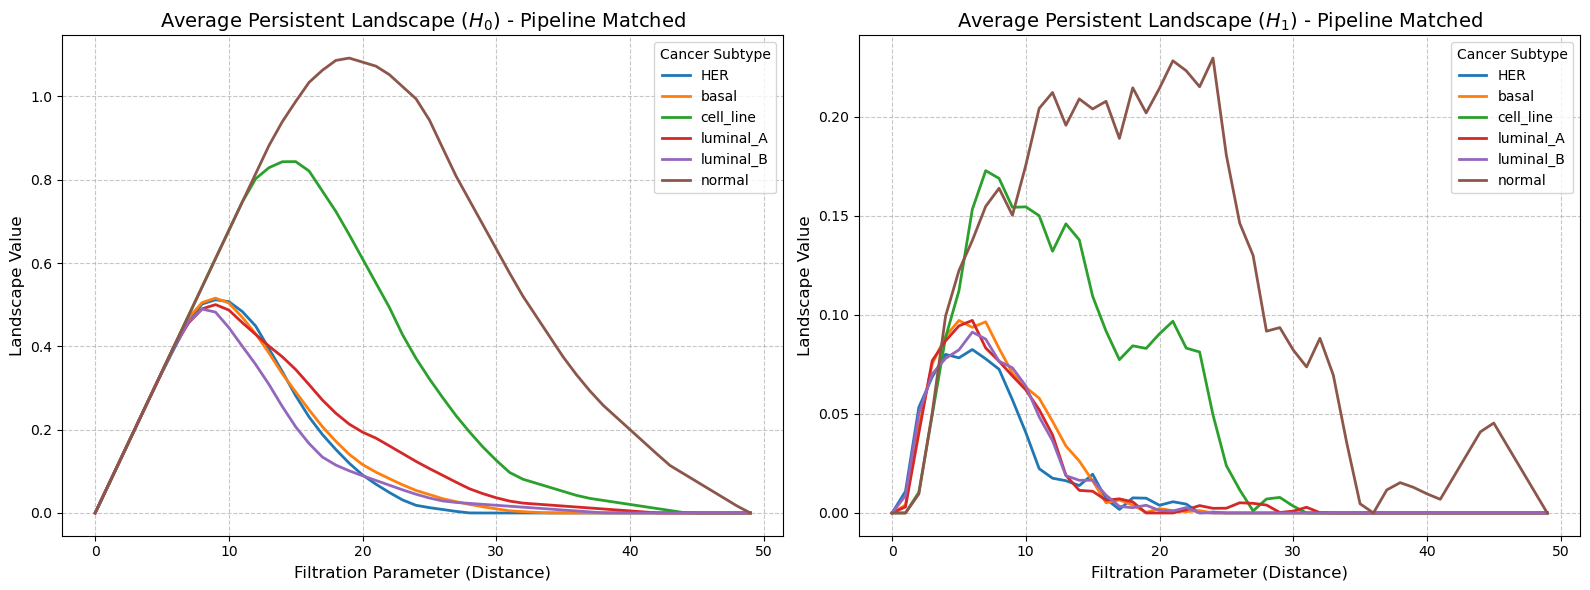

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

# 1. EXACT PREPROCESSING FROM THE PIPELINE
# We must scale and select the exact same 3000 genes that the Random Forest sees
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=3000)
X_reduced_consistent = selector.fit_transform(X_scaled, y_encoded)

# 2. EXACT TDA PARAMETERS FROM THE PIPELINE
# Using time_delay=4 and dimension=3 to match the enriched pipeline
embedder = TakensEmbedding(time_delay=4, dimension=3)
X_embedded_consistent = embedder.fit_transform(X_reduced_consistent)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams_consistent = rips.fit_transform(X_embedded_consistent)

# Extract landscapes using exactly 50 bins
landscape_extractor = PersistenceLandscape(n_bins=50)
landscapes_consistent = landscape_extractor.fit_transform(diagrams_consistent)

# 3. SETUP PLOTTING
homology_dims = [0, 1]
classes = le.classes_

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 4. CALCULATE MEAN LANDSCAPES AND PLOT
for class_idx, class_name in enumerate(classes):
    sample_indices = np.where(y_encoded == class_idx)[0]
    class_landscapes = landscapes_consistent[sample_indices]
    
    # Calculate the average (Fréchet mean equivalent for landscapes)
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    # Plot H0
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    # Plot H1
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

# Formatting H0 plot
axes[0].set_title('Average Persistent Landscape ($H_0$) - Pipeline Matched', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Formatting H1 plot
axes[1].set_title('Average Persistent Landscape ($H_1$) - Pipeline Matched', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

print("Generating out-of-fold predictions for detailed classification reports...\n")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 1. Evaluate Baseline (You need to define baseline_pipeline as in the previous example)
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=-1)

# 2. Evaluate Enriched Pipeline
y_pred_enriched = cross_val_predict(enriched_pipeline, X, y_encoded, cv=cv, n_jobs=-1)

print("=== Baseline (Raw Genes) ===")
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

print("\n=== Enriched Pipeline (Raw Genes + TDA) ===")
print(classification_report(y_encoded, y_pred_enriched, target_names=le.classes_))

Generating out-of-fold predictions for detailed classification reports...


=== Enriched Pipeline (Raw Genes + TDA) ===
              precision    recall  f1-score   support

         HER       0.97      0.93      0.95        30
       basal       0.95      0.98      0.96        41
   cell_line       1.00      1.00      1.00        14
   luminal_A       0.93      0.93      0.93        29
   luminal_B       0.93      0.93      0.93        30
      normal       1.00      1.00      1.00         7

    accuracy                           0.95       151
   macro avg       0.96      0.96      0.96       151
weighted avg       0.95      0.95      0.95       151



In [ ]:
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=-1)
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))


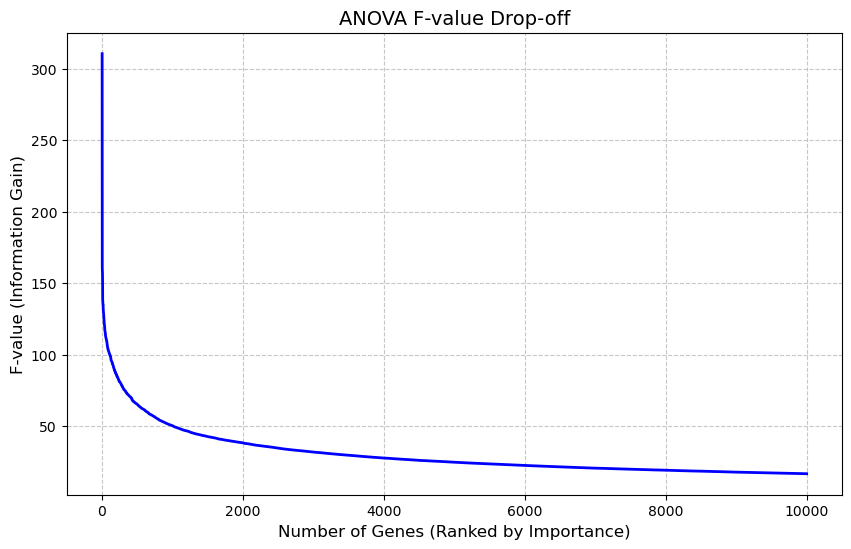


=== Statistical Feature Selection Results ===
Total original genes: 54676
Genes with TRUE statistical significance (FDR alpha=0.01): 45073
Percentage of useful genome: 82.44%


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import f_classif, SelectFdr

# 1. Load Data
df = pd.read_csv('Breast_GSE45827.csv')
target_col = df.columns[0] if 'type' not in df.columns else 'type'

X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calculate ANOVA F-values and p-values for ALL 54,000 genes
f_values, p_values = f_classif(X_scaled, y_encoded)

# --- VISUAL APPROACH: The Elbow Method ---
# Sort F-values in descending order
f_values_sorted = np.sort(f_values)[::-1]

plt.figure(figsize=(10, 6))
# Plotting only the top 10,000 genes to clearly see the elbow (the rest is usually flat noise)
plt.plot(range(1, 10001), f_values_sorted[:10000], linewidth=2, color='blue')
plt.title('ANOVA F-value Drop-off', fontsize=14)
plt.xlabel('Number of Genes (Ranked by Importance)', fontsize=12)
plt.ylabel('F-value (Information Gain)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('f_value_elbow_plot.png', dpi=300)
plt.show()

# --- STATISTICAL APPROACH: False Discovery Rate (FDR) ---
# We use an alpha of 0.01 (allowing only 1% false positives among the selected genes)
fdr_selector = SelectFdr(score_func=f_classif, alpha=0.01)
X_fdr_selected = fdr_selector.fit_transform(X_scaled, y_encoded)

# Get the boolean mask of selected genes to count them
genes_kept_mask = fdr_selector.get_support()
n_genes_kept = np.sum(genes_kept_mask)

print(f"\n=== Statistical Feature Selection Results ===")
print(f"Total original genes: {X_scaled.shape[1]}")
print(f"Genes with TRUE statistical significance (FDR alpha=0.01): {n_genes_kept}")
print(f"Percentage of useful genome: {(n_genes_kept / X_scaled.shape[1]) * 100:.2f}%")

# CLEAR CODE BELOW

#### Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn imports
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.metrics import classification_report, accuracy_score

# Giotto-TDA imports
from gtda.time_series import TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

#### Data Loading and Preparation

In [64]:
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Shared parameters for a fair baseline vs. TDA comparison
N_GENES = 3000 
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

#### Baseline Pipeline (Raw Genes Only)

In [65]:
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

#### Enriched Pipeline (Raw Genes + TDA)


In [66]:
# A. Define the Topological Extraction Branch
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_vectorizers = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

tda_branch = Pipeline([
    ('embedding', TakensEmbedding(time_delay=4, dimension=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_vectorizers)
])

# B. Define the Raw Features Branch
raw_branch = FunctionTransformer(lambda X: X)

# C. Combine Both Branches (Fusion)
combined_features = FeatureUnion([
    ('raw_genes', raw_branch),         # Passes the selected N_GENES
    ('tda_topology', tda_branch)       # Passes the flattened TDA features
])

# D. Build the Master Enriched Pipeline
enriched_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('feature_fusion', combined_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])


#### Evaluation and Reporting

In [67]:

print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} original genes.")
print(f"Comparing models using top {N_GENES} genes...\n")

# Run predictions for Baseline
print("Generating out-of-fold predictions for Baseline Pipeline...")
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=1)

# Run predictions for Enriched
print("Generating out-of-fold predictions for Enriched Pipeline...")
y_pred_enriched = cross_val_predict(enriched_pipeline, X, y_encoded, cv=cv, n_jobs=1)

# Print Final Reports
print("\n" + "="*50)
print(" BASELINE PIPELINE REPORT (RAW GENES ONLY)")
print("="*50)
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_baseline):.4f}\n")
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

print("\n" + "="*50)
print(" ENRICHED PIPELINE REPORT (RAW GENES + TDA)")
print("="*50)
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_enriched):.4f}\n")
print(classification_report(y_encoded, y_pred_enriched, target_names=le.classes_))

Dataset shape: 151 samples, 54676 original genes.
Comparing models using top 3000 genes...

Generating out-of-fold predictions for Baseline Pipeline...
Generating out-of-fold predictions for Enriched Pipeline...

 BASELINE PIPELINE REPORT (RAW GENES ONLY)
Global Accuracy: 0.9272

              precision    recall  f1-score   support

         HER       0.93      0.93      0.93        30
       basal       0.95      0.95      0.95        41
   cell_line       1.00      1.00      1.00        14
   luminal_A       0.87      0.90      0.88        29
   luminal_B       0.90      0.90      0.90        30
      normal       1.00      0.86      0.92         7

    accuracy                           0.93       151
   macro avg       0.94      0.92      0.93       151
weighted avg       0.93      0.93      0.93       151


 ENRICHED PIPELINE REPORT (RAW GENES + TDA)
Global Accuracy: 0.9536

              precision    recall  f1-score   support

         HER       0.97      0.93      0.95        

#### Exact Preprocessing from the Pipeline

In [68]:
# We use the N_GENES constant defined in the master script to ensure 100% consistency
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=N_GENES)
X_reduced_consistent = selector.fit_transform(X_scaled, y_encoded)

#### Exact TDA Extraction (time_delay=4, dim=3, bins=50)

In [69]:
print(f"Extracting TDA features for {N_GENES} genes...")
embedder = TakensEmbedding(time_delay=4, dimension=3)
X_embedded_consistent = embedder.fit_transform(X_reduced_consistent)

rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams_consistent = rips.fit_transform(X_embedded_consistent)

landscape_extractor = PersistenceLandscape(n_bins=50)
landscapes_consistent = landscape_extractor.fit_transform(diagrams_consistent)

Extracting TDA features for 3000 genes...


#### Calculate Mean Landscapes and Plot

Plotting Fréchet means of Persistence Landscapes...


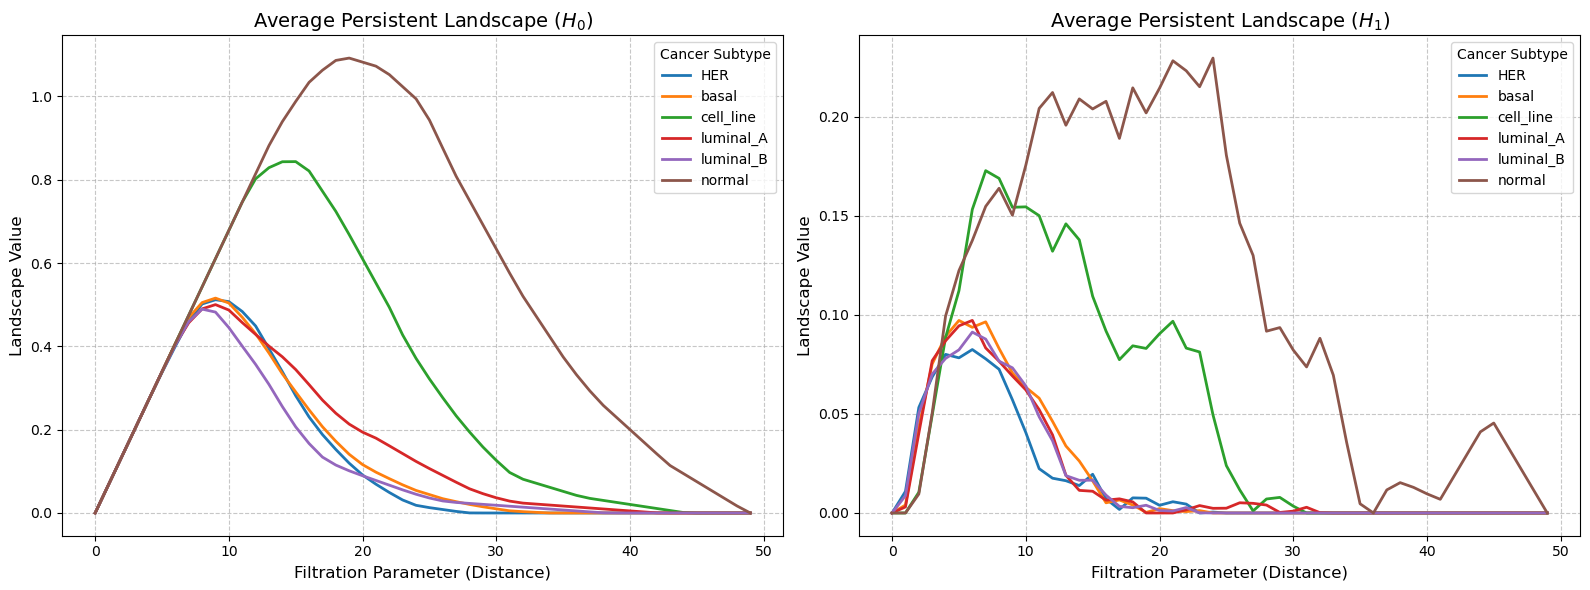

In [70]:
print("Plotting Fréchet means of Persistence Landscapes...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_idx, class_name in enumerate(le.classes_):
    # Isolate landscapes for the specific subtype
    sample_indices = np.where(y_encoded == class_idx)[0]
    class_landscapes = landscapes_consistent[sample_indices]
    
    # Calculate the average (axis=0 averages across all patients in this class)
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    # Plot H0 and H1
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

# Formatting H0 (Connected Components)
axes[0].set_title('Average Persistent Landscape ($H_0$)', fontsize=14)
axes[0].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Formatting H1 (Loops/Holes)
axes[1].set_title('Average Persistent Landscape ($H_1$)', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f'BreastCancer_plots/average_persistence_landscapes_{N_GENES}genes.png', dpi=300)
plt.show()

# FINAL WORKFLOW

In [122]:
import pandas as pd
import numpy as np

# Scikit-learn imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score

# Giotto-TDA imports
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape, Amplitude, BettiCurve

# ==========================================
# 0. Custom Transformer: Biologically Grounded TDA
# ==========================================
class SingleSampleNetworkTopology(BaseEstimator, TransformerMixin):
    """
    Transforms tabular gene expression data into patient-specific 3D point clouds
    based on the global Gene Co-expression Network topology.
    """
    def __init__(self, n_active_genes=100, embedding_dim=3):
        self.n_active_genes = n_active_genes
        self.embedding_dim = embedding_dim
        self.gene_coords_ = None

    def fit(self, X, y=None):
        # 1. Compute global correlation matrix across all training samples
        # X shape is (n_samples, n_genes). Transpose to correlate genes.
        # Add tiny noise to avoid division by zero for genes with zero variance
        corr = np.corrcoef(X.T + np.random.normal(0, 1e-8, X.T.shape))
        corr = np.nan_to_num(corr, nan=0.0)
        
        # 2. Convert correlation to distance metric: d = 1 - |r|
        # Highly correlated genes (+1 or -1) are close to each other (distance ~0)
        dist_matrix = 1 - np.abs(corr)
        
        # 3. Embed the global gene network into a 3D geometric space
        pca = PCA(n_components=self.embedding_dim, random_state=42)
        self.gene_coords_ = pca.fit_transform(dist_matrix)
        
        return self

    def transform(self, X, y=None):
        point_clouds = []
        
        for sample in X:
            # Find the indices of the most highly expressed genes for this specific patient
            # Since data is standard-scaled, highest values = most overexpressed
            top_gene_indices = np.argsort(sample)[-self.n_active_genes:]
            
            # Retrieve the 3D spatial coordinates of these active genes
            patient_cloud = self.gene_coords_[top_gene_indices]
            point_clouds.append(patient_cloud)
            
        # Return a 3D tensor: [n_samples, n_active_genes, 3] ready for Vietoris-Rips
        return np.array(point_clouds)

# ==========================================
# 1. Data Loading and Preparation
# ==========================================
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Shared parameters for a fair baseline vs. TDA comparison
N_GENES = 3000 
N_A_GENES = 500
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ==========================================
# 2. Baseline Pipeline (Raw Genes Only)
# ==========================================
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# ==========================================
# 3. Enriched Pipeline (Raw Genes + Network TDA)
# ==========================================
flattener = FunctionTransformer(lambda X_tensor: X_tensor.reshape(X_tensor.shape[0], -1))

tda_vectorizers = FeatureUnion([
    ("landscape", Pipeline([
        ("extract", PersistenceLandscape(n_bins=50)), 
        ("flatten", flattener)
    ])),
    ("amplitude", Amplitude(metric="wasserstein")),
    ("betti", Pipeline([
        ("extract", BettiCurve(n_bins=50)), 
        ("flatten", flattener)
    ]))
])

# The mathematically grounded TDA branch
tda_branch = Pipeline([
    # Create patient-specific clouds of top 500 active genes
    ('ssn_topology', SingleSampleNetworkTopology(n_active_genes=N_A_GENES, embedding_dim=3)),
    ('rips', VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)),
    ('tda_features', tda_vectorizers)
])

raw_branch = FunctionTransformer(lambda X: X)

combined_features = FeatureUnion([
    ('raw_genes', raw_branch),         # Passes the selected N_GENES
    ('tda_topology', tda_branch)       # Passes the flattened TDA features
])

enriched_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=N_GENES)),
    ('feature_fusion', combined_features),
    ('classifier', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1))
])

# ==========================================
# 4. Evaluation and Reporting
# ==========================================
print(f"Dataset shape: {X.shape[0]} samples, {X.shape[1]} original genes.")
print(f"Comparing models using top {N_GENES} genes with Single-Sample Network Topology...\n")

print("Generating out-of-fold predictions for Baseline Pipeline...")
y_pred_baseline = cross_val_predict(baseline_pipeline, X, y_encoded, cv=cv, n_jobs=1)

print("Generating out-of-fold predictions for Enriched Pipeline...")
# This step is computationally heavier because it builds a 1000x1000 correlation matrix 
# and runs PCA inside each CV fold.
y_pred_enriched = cross_val_predict(enriched_pipeline, X, y_encoded, cv=cv, n_jobs=1)

# Print Final Reports
print("\n" + "="*50)
print(" BASELINE PIPELINE REPORT (RAW GENES ONLY)")
print("="*50)
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_baseline):.4f}\n")
print(classification_report(y_encoded, y_pred_baseline, target_names=le.classes_))

print("\n" + "="*50)
print(" ENRICHED PIPELINE REPORT (GENES + NETWORK TDA)")
print("="*50)
print(f"Global Accuracy: {accuracy_score(y_encoded, y_pred_enriched):.4f}\n")
print(classification_report(y_encoded, y_pred_enriched, target_names=le.classes_))

Dataset shape: 151 samples, 54676 original genes.
Comparing models using top 3000 genes with Single-Sample Network Topology...

Generating out-of-fold predictions for Baseline Pipeline...
Generating out-of-fold predictions for Enriched Pipeline...

 BASELINE PIPELINE REPORT (RAW GENES ONLY)
Global Accuracy: 0.9272

              precision    recall  f1-score   support

         HER       0.93      0.93      0.93        30
       basal       0.95      0.95      0.95        41
   cell_line       1.00      1.00      1.00        14
   luminal_A       0.87      0.90      0.88        29
   luminal_B       0.90      0.90      0.90        30
      normal       1.00      0.86      0.92         7

    accuracy                           0.93       151
   macro avg       0.94      0.92      0.93       151
weighted avg       0.93      0.93      0.93       151


 ENRICHED PIPELINE REPORT (GENES + NETWORK TDA)
Global Accuracy: 0.9669

              precision    recall  f1-score   support

         HE


 GENERATING TOPOLOGICAL VISUALIZATIONS (NETWORK TDA)
Building Patient-Specific Networks for 3000 genes...
Calculating Vietoris-Rips persistence...
Plotting Fréchet means of Persistence Landscapes...


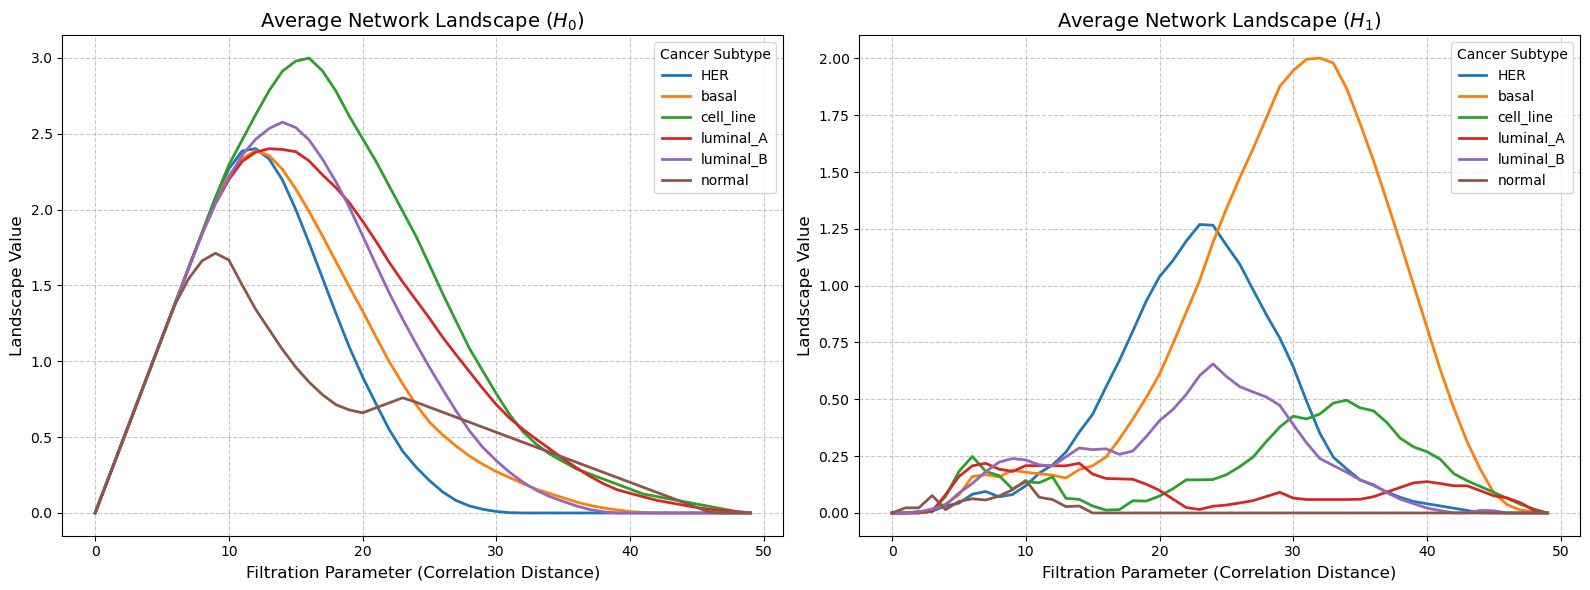

In [123]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceLandscape

print("\n" + "="*50)
print(" GENERATING TOPOLOGICAL VISUALIZATIONS (NETWORK TDA)")
print("="*50)

# ==========================================
# 1. Exact Preprocessing from the Pipeline
# ==========================================
# We use the N_GENES constant (e.g., 1000) from the master script
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=N_GENES)
X_reduced_consistent = selector.fit_transform(X_scaled, y_encoded)

# ==========================================
# 2. Extract Biologically Grounded TDA Features
# ==========================================
print(f"Building Patient-Specific Networks for {N_GENES} genes...")
# Initialize our custom transformer
network_topology = SingleSampleNetworkTopology(n_active_genes=100, embedding_dim=3)

# Fit the global map and transform patients into 3D biological point clouds
X_point_clouds = network_topology.fit_transform(X_reduced_consistent)

print("Calculating Vietoris-Rips persistence...")
rips = VietorisRipsPersistence(homology_dimensions=[0, 1], n_jobs=-1)
diagrams_network = rips.fit_transform(X_point_clouds)

# Extract Persistence Landscapes using exactly 50 bins
landscape_extractor = PersistenceLandscape(n_bins=50)
landscapes_network = landscape_extractor.fit_transform(diagrams_network)

# ==========================================
# 3. Calculate Mean Landscapes and Plot
# ==========================================
print("Plotting Fréchet means of Persistence Landscapes...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for class_idx, class_name in enumerate(le.classes_):
    # Isolate landscapes for the specific subtype
    sample_indices = np.where(y_encoded == class_idx)[0]
    class_landscapes = landscapes_network[sample_indices]
    
    # Calculate the average (axis=0 averages across all patients in this class)
    avg_landscape = np.mean(class_landscapes, axis=0)
    
    # Plot H0 (Connected Components)
    axes[0].plot(avg_landscape[0], label=class_name, linewidth=2)
    # Plot H1 (Loops/Holes)
    axes[1].plot(avg_landscape[1], label=class_name, linewidth=2)

# Formatting H0 
axes[0].set_title('Average Network Landscape ($H_0$)', fontsize=14)
# Here distance is 1 - |correlation|
axes[0].set_xlabel('Filtration Parameter (Correlation Distance)', fontsize=12)
axes[0].set_ylabel('Landscape Value', fontsize=12)
axes[0].legend(title="Cancer Subtype")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Formatting H1 
axes[1].set_title('Average Network Landscape ($H_1$)', fontsize=14)
axes[1].set_xlabel('Filtration Parameter (Correlation Distance)', fontsize=12)
axes[1].set_ylabel('Landscape Value', fontsize=12)
axes[1].legend(title="Cancer Subtype")
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f'BreastCancer_plots/500_better_average_network_landscapes_{N_GENES}genes.png', dpi=300)
plt.show()


 EXTRACTING RANDOM FOREST FEATURE IMPORTANCES
Fitting the model on the full dataset...


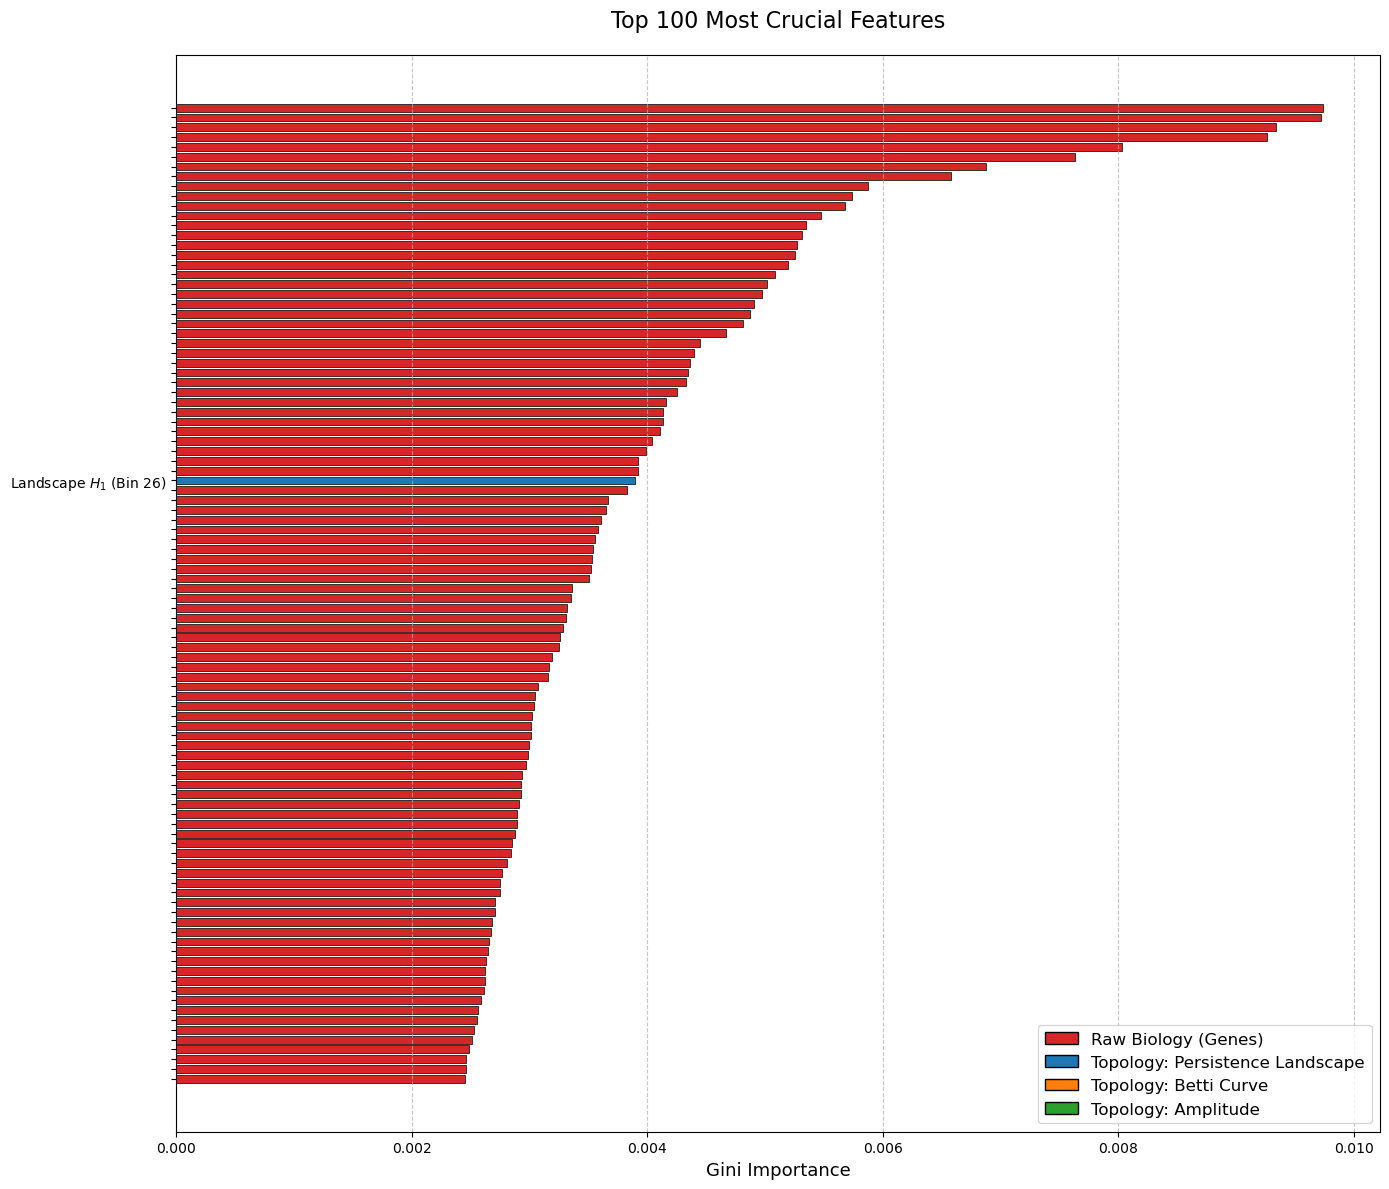

In [124]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

print("\n" + "="*50)
print(" EXTRACTING RANDOM FOREST FEATURE IMPORTANCES")
print("="*50)

# 1. Fit the Enriched Pipeline on the entire dataset to finalize the model
print("Fitting the model on the full dataset...")
enriched_pipeline.fit(X, y_encoded)

# 2. Extract the trained Random Forest classifier from the pipeline
rf_model = enriched_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

# 3. Reconstruct the precise names of all 1202 features
# A. Raw Genes (1000 features from ANOVA)
gene_names = [f"Selected Gene (ANOVA Rank {i+1})" for i in range(N_GENES)]

# B. TDA Features (202 features from the FeatureUnion)
# Landscapes: 2 dimensions (H0, H1) * 50 bins = 100 features
landscape_names = [f"Landscape $H_{h}$ (Bin {b+1})" for h in [0, 1] for b in range(50)]

# Amplitude: 2 dimensions (H0, H1) = 2 features
amplitude_names = ["Amplitude $H_0$", "Amplitude $H_1$"]

# Betti Curves: 2 dimensions (H0, H1) * 50 bins = 100 features
betti_names = [f"Betti Curve $H_{h}$ (Bin {b+1})" for h in [0, 1] for b in range(50)]

# Concatenate all names exactly in the order they emerge from FeatureUnion
tda_names = landscape_names + amplitude_names + betti_names
feature_names = np.array(gene_names + tda_names)

# Sanity check to prevent indexing errors
assert len(importances) == len(feature_names), f"Mismatch: {len(importances)} importances vs {len(feature_names)} names."

# 4. Sort and isolate the Top N most powerful predictors
top_n = 100 # Zwiększyliśmy, żeby objąć więcej cech
indices = np.argsort(importances)[::-1][:top_n]
top_importances = importances[indices]
top_names = feature_names[indices]

# MASKOWANIE NAZW: Pokazuj tylko cechy TDA, geny zastąp pustym tekstem
display_names = []
for name in top_names:
    if "Landscape" in name or "Betti" in name or "Amplitude" in name:
        display_names.append(name)
    else:
        display_names.append("") # Ukryj surowe geny

# 5. Build the visual representation
plt.figure(figsize=(14, 12)) # Delikatnie wyższy wykres

# Assign distinct colors to distinguish Biology (Genes) from Geometry (TDA)
colors = []
for name in top_names:
    if "Landscape" in name:
        colors.append('#1f77b4') # Blue
    elif "Betti" in name:
        colors.append('#ff7f0e') # Orange
    elif "Amplitude" in name:
        colors.append('#2ca02c') # Green
    else:
        colors.append('#d62728') # Red for Genes

# We reverse the arrays [::-1] so the highest value sits at the top of the horizontal bar chart
bars = plt.barh(range(top_n), top_importances[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)

# Przekazujemy naszą przefiltrowaną listę display_names (zwiększona czcionka)
plt.yticks(range(top_n), display_names[::-1], fontsize=10)
plt.xlabel('Gini Importance', fontsize=13)
plt.title(f'Top {top_n} Most Crucial Features', fontsize=16, pad=20)

# Create a custom legend
legend_elements = [
    Patch(facecolor='#d62728', edgecolor='black', label='Raw Biology (Genes)'),
    Patch(facecolor='#1f77b4', edgecolor='black', label='Topology: Persistence Landscape'),
    Patch(facecolor='#ff7f0e', edgecolor='black', label='Topology: Betti Curve'),
    Patch(facecolor='#2ca02c', edgecolor='black', label='Topology: Amplitude')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(f'BreastCancer_plots/{N_A_GENES}_{top_n}_feature_importances_{N_GENES}genes.png', dpi=300)
plt.show()

Wczytywanie prawdziwych danych z CuMiDa...
Budowanie mapy korelacji dla 1000 genów...
Rysowanie chmury punktów dla pacjenta 13 (Podtyp: basal)...


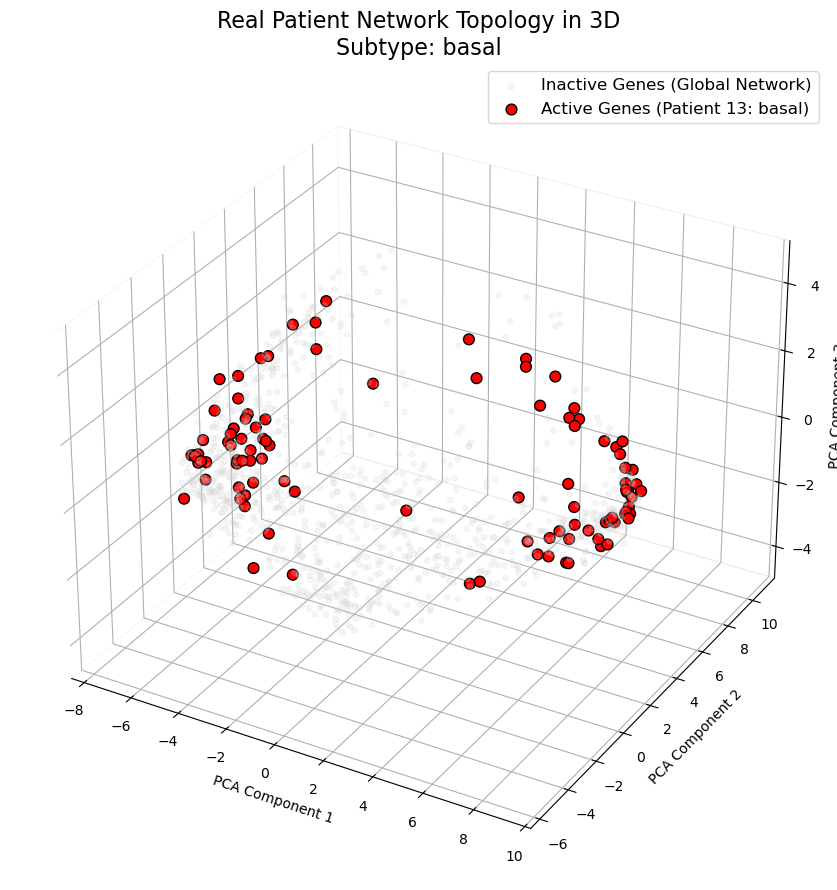

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

print("Wczytywanie prawdziwych danych z CuMiDa...")
# 1. Wczytanie prawdziwych danych
file_path = 'Breast_GSE45827.csv'
df = pd.read_csv(file_path)

target_col = df.columns[0] if 'type' not in df.columns else 'type'
X = df.drop(columns=[target_col]).values
y = df[target_col].values

# 2. Preprocessing (dokładnie jak w Pipeline)
N_GENES = 1000
N_ACTIVE = 100

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=N_GENES)
X_selected = selector.fit_transform(X_scaled, y)

print("Budowanie mapy korelacji dla 1000 genów...")
# 3. Budowa prawdziwej mapy korelacji 
corr = np.corrcoef(X_selected.T + np.random.normal(0, 1e-8, X_selected.T.shape))
corr = np.nan_to_num(corr, nan=0.0)
dist_matrix = 1 - np.abs(corr)

pca = PCA(n_components=3, random_state=42)
global_coords = pca.fit_transform(dist_matrix)

# 4. Wybór PRAWDZIWEGO pacjenta
# Bierzemy pacjenta o indeksie 0 (zobaczymy, jaki to podtyp na wykresie)
patient_idx = 13
patient_class = y[patient_idx]
patient_data = X_selected[patient_idx]

# Znajdujemy 100 najbardziej aktywnych genów dla TEGO KONKRETNEGO pacjenta
active_indices = np.argsort(patient_data)[-N_ACTIVE:]
patient_cloud = global_coords[active_indices]

print(f"Rysowanie chmury punktów dla pacjenta {patient_idx} (Podtyp: {patient_class})...")
# 5. Rysowanie w 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Tworzymy maskę dla genów, które u tego pacjenta "śpią" (są nieaktywne)
inactive_mask = np.ones(N_GENES, dtype=bool)
inactive_mask[active_indices] = False

# Rysujemy TŁO (900 genów)
ax.scatter(global_coords[inactive_mask, 0], 
           global_coords[inactive_mask, 1], 
           global_coords[inactive_mask, 2], 
           c='lightgray', alpha=0.2, s=15, label='Inactive Genes (Global Network)')

# Rysujemy AKTYWNE geny tego pacjenta (100 punktów, dla których policzy się Rips)
ax.scatter(patient_cloud[:, 0], 
           patient_cloud[:, 1], 
           patient_cloud[:, 2], 
           c='red', alpha=1.0, s=60, edgecolors='black', 
           label=f'Active Genes (Patient {patient_idx}: {patient_class})')

ax.set_title(f"Real Patient Network Topology in 3D\nSubtype: {patient_class}", fontsize=16)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.legend(fontsize=12)

# Poprawia widoczność tła 3D
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

plt.tight_layout()
plt.savefig(f'BreastCancer_plots/patient_{patient_idx}_3D_topology_subtype_{patient_class}.png', dpi=300)
plt.show()